In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv(r"C:\Users\parma\Downloads\ICU_DATASET.csv")
df.head()

,patient_id,age,gender,admission_type,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
0,PAT000001,32,Male,Urgent,3.75,136.06,19.64,162.01,127.16,104.04,...,73.71,7.77,4245.99,0,0,6.32,15.65,10.50,0,0
1,PAT000002,46,Male,Urgent,2.91,108.95,7.79,124.18,94.79,131.05,...,78.36,5.06,1267.36,0,1,29.00,33.29,6.09,0,1
2,PAT000003,87,Male,Urgent,6.84,95.21,7.44,117.54,89.35,171.84,...,168.41,1.89,4863.13,1,1,26.95,25.93,18.44,0,1
3,PAT000004,21,Male,Emergency,1.96,63.62,11.51,82.22,51.84,164.59,...,214.40,1.06,4940.99,1,0,1.16,33.54,14.14,0,1
4,PAT000005,21,Male,Urgent,7.71,65.92,12.17,74.98,39.34,146.10,...,201.33,5.28,4492.46,0,0,21.68,31.63,11.23,0,0


In [13]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df = df.fillna(df.median(numeric_only=True))

# Drop useless column
df = df.drop("patient_id", axis=1)

# Convert categorical to numeric
df = pd.get_dummies(df, columns=["gender", "admission_type"], drop_first=True)

In [14]:
X = df.drop("mortality_label", axis=1)
y = df["mortality_label"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [18]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]

In [19]:
def evaluate(y_test, pred, prob):
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("AUC:", roc_auc_score(y_test, prob))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
    print("-" * 40)

print("Logistic Regression")
evaluate(y_test, lr_pred, lr_prob)

print("Random Forest")
evaluate(y_test, rf_pred, rf_prob)

Logistic Regression
Accuracy: 0.7683333333333333
Precision: 0.625
Recall: 0.02844950213371266
AUC: 0.6451503631120065
Confusion Matrix:
 [[2285   12]
 [ 683   20]]
----------------------------------------
Random Forest
Accuracy: 0.7646666666666667
Precision: 0.2857142857142857
Recall: 0.002844950213371266
AUC: 0.6086066246343954
Confusion Matrix:
 [[2292    5]
 [ 701    2]]
----------------------------------------


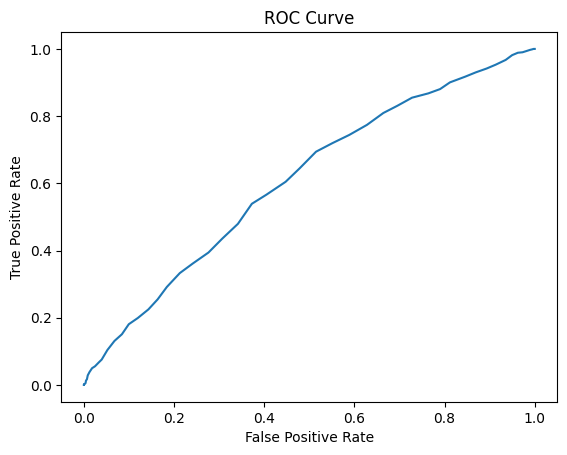

In [29]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Use best model probabilities
fpr, tpr, _ = roc_curve(y_test, rf_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [27]:
# Compare models
lr_auc = roc_auc_score(y_test, lr_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Logistic Regression AUC:", lr_auc)
print("Random Forest AUC:", rf_auc)

Logistic Regression AUC: 0.6451503631120065
Random Forest AUC: 0.6086066246343954


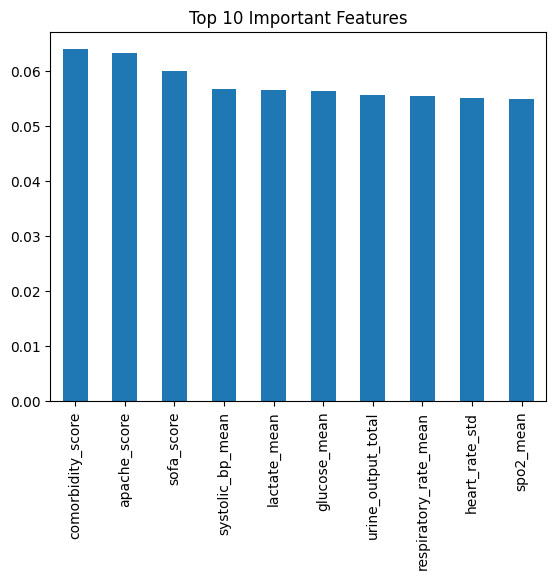

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

In [28]:
import pickle

if rf_auc > lr_auc:
    best_model = rf
    print("Using Random Forest")
else:
    best_model = lr
    print("Using Logistic Regression")

pickle.dump(best_model, open("../models/model.pkl", "wb"))
pickle.dump(scaler, open("../models/scaler.pkl", "wb"))
pickle.dump(X.columns, open("../models/columns.pkl", "wb"))

Using Logistic Regression


In [23]:
def predict_risk(input_data):
    input_array = np.array(input_data).reshape(1, -1)
    input_scaled = scaler.transform(input_array)
    
    prob = best_model.predict_proba(input_scaled)[0][1]
    
    if prob < 0.3:
        risk = "Low Risk"
    elif prob < 0.7:
        risk = "Medium Risk"
    else:
        risk = "High Risk"
    
    return prob, risk

In [24]:
sample = X.iloc[0].values
prob, risk = predict_risk(sample)

print("Probability:", prob)
print("Risk Level:", risk)

Probability: 0.04
Risk Level: Low Risk


c:\Users\parma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
